# PricePilot — EDA & Price Elasticity Modelling
**Three-Tier Architecture: Dedicated OLS → Category Ridge → Global Ridge**

This notebook documents the data analysis and modelling decisions behind `train/train.py`.
It covers:
1. Data quality and price variation analysis
2. Feature engineering rationale
3. Three-tier model design, trade-offs, and fit diagnostics
4. Cross-tier comparison and production tier assignment
5. Key findings and recommendations


In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import cross_val_score

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 120)

DATA_PATH = Path("../data/dataset.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["ad_spend_eur"] = df["ad_spend_eur"].fillna(0.0)

print(f"Loaded {len(df):,} rows from {DATA_PATH}")


Loaded 131,028 rows from ..\data\dataset.csv


## 1. Dataset Overview


In [2]:
print("=" * 60)
print("DATASET SHAPE & DIMENSIONS")
print("=" * 60)
print(f"  Rows          : {len(df):,}")
print(f"  Columns       : {df.shape[1]}")
print(f"  Date range    : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"  Calendar days : {(df['date'].max() - df['date'].min()).days + 1}")
print(f"  SKUs (product_id)  : {df['product_id'].nunique()}")
print(f"  Markets            : {sorted(df['market'].unique())}")
print(f"  Categories         : {sorted(df['category'].unique())}")
print()
print("NULL COUNTS PER COLUMN (before ad_spend fill)")
raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
print(raw.isnull().sum().to_string())
print()
df.head()


DATASET SHAPE & DIMENSIONS
  Rows          : 131,028
  Columns       : 11
  Date range    : 2024-01-01 -> 2025-12-31
  Calendar days : 731
  SKUs (product_id)  : 60
  Markets            : ['CH', 'DE', 'FR']
  Categories         : ['Ceiling Lights', 'Floor Lamps', 'Outdoor Lighting', 'Pendant Lights', 'Smart Lighting', 'Wall Lights']

NULL COUNTS PER COLUMN (before ad_spend fill)
date                  0
product_id            0
product_name          0
category              0
brand                 0
market                0
unit_price_eur        0
unit_cost_eur         0
units_sold            0
web_sessions          0
ad_spend_eur      19737



,date,product_id,product_name,category,brand,market,unit_price_eur,unit_cost_eur,units_sold,web_sessions,ad_spend_eur
0,2024-01-01,SKU-1000,Pendant Light 'Malia',Pendant Lights,Casaluce,DE,86.9500,43.7200,0,81,7.9400
1,2024-01-01,SKU-1000,Pendant Light 'Malia',Pendant Lights,Casaluce,FR,89.9500,43.7200,1,21,2.2900
2,2024-01-01,SKU-1000,Pendant Light 'Malia',Pendant Lights,Casaluce,CH,95.9500,43.7200,1,14,1.2700
3,2024-01-02,SKU-1000,Pendant Light 'Malia',Pendant Lights,Casaluce,DE,86.9500,43.7200,1,52,2.7300
4,2024-01-02,SKU-1000,Pendant Light 'Malia',Pendant Lights,Casaluce,FR,89.9500,43.7200,0,22,1.3600


In [3]:
# ad_spend_eur null fill — must happen before any downstream computation.
# NaN means no campaign was running; using median would systematically
# overstate advertising effects. Zero maps cleanly to ln(1+0) = 0 contribution.
print("ad_spend_eur nulls before fill:", raw["ad_spend_eur"].isnull().sum())
print("ad_spend_eur nulls after fill :", df["ad_spend_eur"].isnull().sum())
print()
print("Updated null counts:")
print(df.isnull().sum().to_string())


ad_spend_eur nulls before fill: 19737
ad_spend_eur nulls after fill : 0

Updated null counts:
date              0
product_id        0
product_name      0
category          0
brand             0
market            0
unit_price_eur    0
unit_cost_eur     0
units_sold        0
web_sessions      0
ad_spend_eur      0


## 2. Univariate EDA


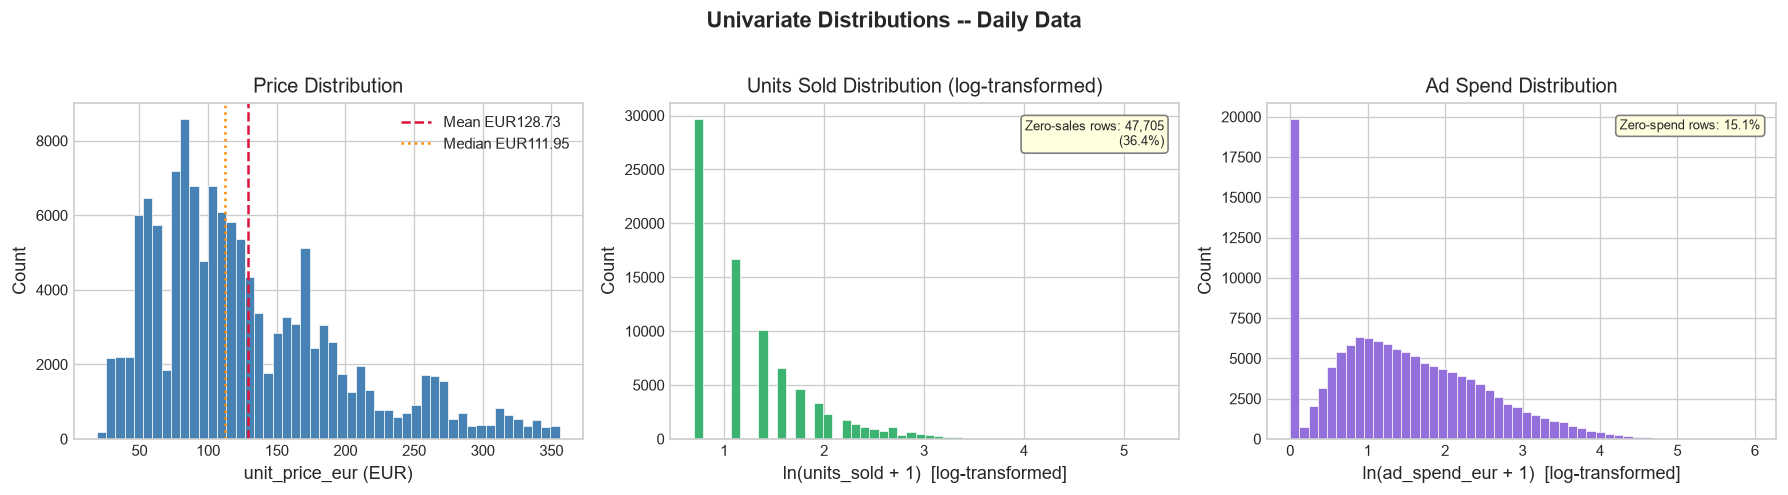

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: unit price distribution
ax = axes[0]
ax.hist(df["unit_price_eur"], bins=50, color="steelblue", edgecolor="white", linewidth=0.4)
mean_p = df["unit_price_eur"].mean()
median_p = df["unit_price_eur"].median()
ax.axvline(mean_p, color="crimson", lw=1.5, linestyle="--", label=f"Mean EUR{mean_p:.2f}")
ax.axvline(median_p, color="darkorange", lw=1.5, linestyle=":", label=f"Median EUR{median_p:.2f}")
ax.set_xlabel("unit_price_eur (EUR)")
ax.set_ylabel("Count")
ax.set_title("Price Distribution")
ax.legend()

# Panel 2: units sold (log-transformed)
ax = axes[1]
positive_units = df["units_sold"][df["units_sold"] > 0]
ax.hist(np.log1p(positive_units), bins=50, color="mediumseagreen", edgecolor="white", linewidth=0.4)
ax.set_xlabel("ln(units_sold + 1)  [log-transformed]")
ax.set_ylabel("Count")
ax.set_title("Units Sold Distribution (log-transformed)")
ax.text(0.97, 0.95, f"Zero-sales rows: {(df['units_sold']==0).sum():,}\n({(df['units_sold']==0).mean()*100:.1f}%)",
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))

# Panel 3: ad_spend distribution
ax = axes[2]
ax.hist(np.log1p(df["ad_spend_eur"]), bins=50, color="mediumpurple", edgecolor="white", linewidth=0.4)
ax.set_xlabel("ln(ad_spend_eur + 1)  [log-transformed]")
ax.set_ylabel("Count")
ax.set_title("Ad Spend Distribution")
zero_pct = (df["ad_spend_eur"] == 0).mean() * 100
ax.text(0.97, 0.95, f"Zero-spend rows: {zero_pct:.1f}%",
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))

plt.suptitle("Univariate Distributions -- Daily Data", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [6]:
# Zero-sales rate per market -- critical for understanding tier-1 eligibility
zero_rate = (
    df.groupby("market")["units_sold"]
    .apply(lambda s: (s == 0).mean() * 100)
    .rename("zero_sales_pct")
    .reset_index()
)
print("Zero-sales rate by market:")
print(zero_rate.to_string(index=False))
print()
print("Comment: CH has high zero days -- this compresses weekly signal")
print("and motivates the >=8 non-zero weeks threshold in train_dedicated().")


Zero-sales rate by market:
market  zero_sales_pct
    CH         54.4464
    DE         16.6018
    FR         38.1766

Comment: CH has high zero days -- this compresses weekly signal
and motivates the >=8 non-zero weeks threshold in train_dedicated().


Gross margin distribution:
count   131028.0000
mean         0.4849
std          0.0644
min          0.1182
25%          0.4412
50%          0.4927
75%          0.5340
max          0.6026

Mean margin : 48.5%
Std  margin : 6.4%
Range       : 11.8% -- 60.3%


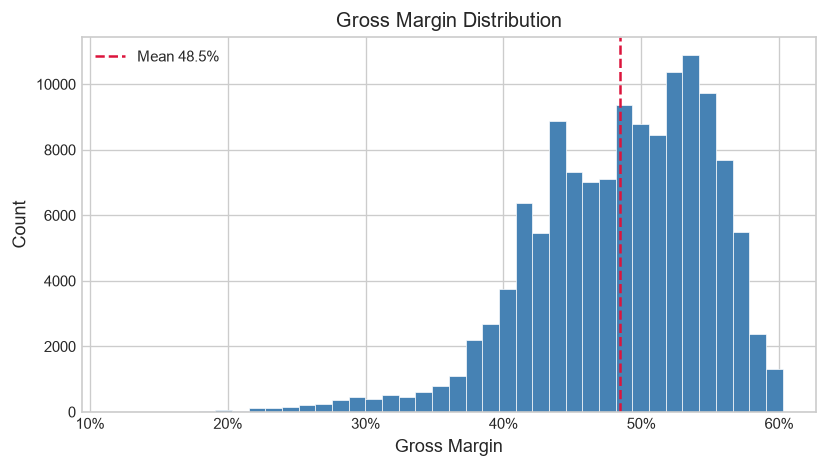

In [7]:
# Margin analysis -- needed to validate profit-curve calculations downstream
df["margin"] = (df["unit_price_eur"] - df["unit_cost_eur"]) / df["unit_price_eur"]

print("Gross margin distribution:")
print(df["margin"].describe().to_string())
print(f"\nMean margin : {df['margin'].mean()*100:.1f}%")
print(f"Std  margin : {df['margin'].std()*100:.1f}%")
print(f"Range       : {df['margin'].min()*100:.1f}% -- {df['margin'].max()*100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["margin"], bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(df["margin"].mean(), color="crimson", lw=1.5, linestyle="--",
           label=f"Mean {df['margin'].mean()*100:.1f}%")
ax.set_xlabel("Gross Margin")
ax.set_ylabel("Count")
ax.set_title("Gross Margin Distribution")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()


## 3. Price Variation Analysis -- Eligibility for Tier 1


In [8]:
# Compute eligibility metrics at the SKU x market level.
# Tier 1 requires: >=8 non-zero weeks AND >=3 distinct prices (rounded to 2dp).

def weekly_aggregate(daily: pd.DataFrame) -> pd.DataFrame:
    """Collapse daily rows to one row per ISO week."""
    d = daily.copy()
    d["week"] = d["date"].dt.to_period("W").dt.start_time
    weekly = (
        d.groupby("week")
        .agg(
            avg_price=("unit_price_eur", "mean"),
            units=("units_sold", "sum"),
            ad_spend=("ad_spend_eur", "sum"),
        )
        .reset_index()
    )
    return weekly


eligibility_rows = []
for (pid, mkt), grp in df.groupby(["product_id", "market"]):
    w = weekly_aggregate(grp)
    w_nz = w[w["units"] > 0]
    n_weeks = len(w_nz)
    n_prices = w_nz["avg_price"].round(2).nunique() if n_weeks > 0 else 0
    eligible = (n_weeks >= 8) and (n_prices >= 3)
    eligibility_rows.append({
        "product_id": pid, "market": mkt,
        "n_non_zero_weeks": n_weeks,
        "n_distinct_prices": n_prices,
        "eligible": eligible,
    })

elig_df = pd.DataFrame(eligibility_rows)
pct_eligible = elig_df["eligible"].mean() * 100

print(f"Total SKU x market pairs : {len(elig_df)}")
print(f"Eligible for Tier 1      : {elig_df['eligible'].sum()} ({pct_eligible:.1f}%)")
print(f"Ineligible (skip)        : {(~elig_df['eligible']).sum()} ({100-pct_eligible:.1f}%)")
print()
print("Breakdown by market:")
print(
    elig_df.groupby("market")["eligible"]
    .agg(["sum", "mean"])
    .rename(columns={"sum": "n_eligible", "mean": "pct"})
    .assign(pct=lambda x: (x["pct"] * 100).round(1))
    .to_string()
)


Total SKU x market pairs : 180
Eligible for Tier 1      : 180 (100.0%)
Ineligible (skip)        : 0 (0.0%)

Breakdown by market:
        n_eligible      pct
market                     
CH              60 100.0000
DE              60 100.0000
FR              60 100.0000


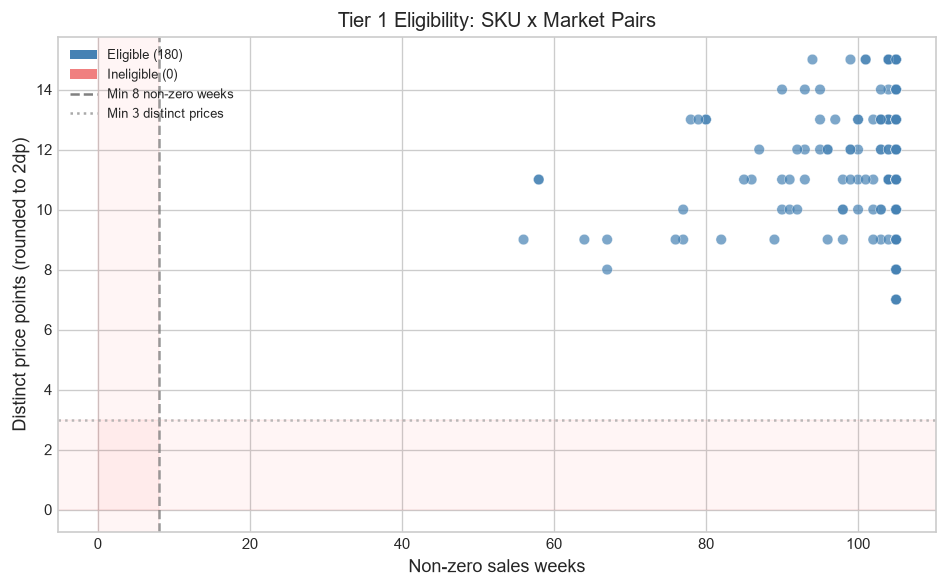

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = elig_df["eligible"].map({True: "steelblue", False: "lightcoral"})
ax.scatter(
    elig_df["n_non_zero_weeks"],
    elig_df["n_distinct_prices"],
    c=colors,
    alpha=0.7, s=40, linewidths=0.3, edgecolors="white"
)

ax.axvline(8, color="gray", lw=1.5, linestyle="--", alpha=0.8, label="Min 8 non-zero weeks")
ax.axhline(3, color="darkgray", lw=1.5, linestyle=":", alpha=0.8, label="Min 3 distinct prices")
ax.axvspan(0, 8, alpha=0.04, color="red")
ax.axhspan(0, 3, alpha=0.04, color="red")

legend_elements = [
    Patch(fc="steelblue", label=f"Eligible ({elig_df['eligible'].sum()})"),
    Patch(fc="lightcoral", label=f"Ineligible ({(~elig_df['eligible']).sum()})"),
    plt.Line2D([0],[0], color="gray", lw=1.5, linestyle="--", label="Min 8 non-zero weeks"),
    plt.Line2D([0],[0], color="darkgray", lw=1.5, linestyle=":", label="Min 3 distinct prices"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=8)

ax.set_xlabel("Non-zero sales weeks")
ax.set_ylabel("Distinct price points (rounded to 2dp)")
ax.set_title("Tier 1 Eligibility: SKU x Market Pairs")
plt.tight_layout()
plt.show()


## 4. Feature Engineering


In [10]:
# Exact copies of weekly_aggregate and design_matrix from train/train.py.
# These must stay in sync with the production training script.

def weekly_aggregate(daily: pd.DataFrame) -> pd.DataFrame:
    """Collapse daily rows to one row per ISO week."""
    df_ = daily.copy()
    df_["week"] = df_["date"].dt.to_period("W").dt.start_time
    weekly = (
        df_.groupby("week")
        .agg(
            avg_price=("unit_price_eur", "mean"),
            units=("units_sold", "sum"),
            ad_spend=("ad_spend_eur", "sum"),
        )
        .reset_index()
    )
    return weekly


def design_matrix(weekly: pd.DataFrame) -> np.ndarray:
    """Features: ln(price), ln(ad_spend + 1), 11 month dummies (Dec is baseline)."""
    ln_price = np.log(weekly["avg_price"].to_numpy())
    ln_ads = np.log1p(weekly["ad_spend"].to_numpy())
    months = pd.get_dummies(weekly["week"].dt.month, dtype=float)
    months = months.reindex(columns=range(1, 12), fill_value=0.0)
    return np.column_stack([ln_price, ln_ads, months.to_numpy()])


# Demonstrate on one SKU
demo_pid = df["product_id"].value_counts().index[0]
demo_mkt = df["market"].value_counts().index[0]
demo_daily = df[(df["product_id"] == demo_pid) & (df["market"] == demo_mkt)].copy()
demo_weekly = weekly_aggregate(demo_daily)

print(f"Feature engineering demo -- SKU={demo_pid}, Market={demo_mkt}")
print(f"  Daily rows  : {len(demo_daily)}")
print(f"  Weekly rows : {len(demo_weekly)} (compression ratio: {len(demo_daily)/len(demo_weekly):.1f}x)")
print()

col_names = ["ln_price", "ln_ads"] + [f"month_{m}" for m in range(1, 12)]
print("Design matrix columns (13 total):")
print(" ".join(col_names))
print()

X_demo = design_matrix(demo_weekly)
dm_df = pd.DataFrame(X_demo, columns=col_names)
print("Design matrix preview (first 5 rows):")
print(dm_df.head().to_string())
print()
print("Feature rationale:")
print("  ln_price      : Log-log spec -> beta directly = % demand change per 1% price change")
print("  ln_ads        : ln(1+spend) -> diminishing returns; zero spend -> ln(1) = 0")
print("  month_1..11   : 11 binary month dummies capturing seasonality")
print("  December (12) : implicit baseline -- highest-volume month, avoids dummy trap")


Feature engineering demo -- SKU=SKU-1000, Market=DE
  Daily rows  : 731
  Weekly rows : 105 (compression ratio: 7.0x)

Design matrix columns (13 total):
ln_price ln_ads month_1 month_2 month_3 month_4 month_5 month_6 month_7 month_8 month_9 month_10 month_11

Design matrix preview (first 5 rows):
   ln_price  ln_ads  month_1  month_2  month_3  month_4  month_5  month_6  month_7  month_8  month_9  month_10  month_11
0    4.4653  3.6692   1.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000    0.0000    0.0000
1    4.4653  3.4049   1.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000    0.0000    0.0000
2    4.4653  3.5456   1.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000    0.0000    0.0000
3    4.4653  3.6715   1.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000    0.0000    0.0000
4    4.3034  3.4494   1.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0

## 5. Tier 1 -- Dedicated OLS (High-Volume SKUs)


Total SKUs     : 60
High-volume    : 8 SKUs (top 50% revenue) -> Tier 1
Mid-volume     : 52 SKUs (remainder) -> Tier 2

High-volume SKUs account for 47.5% of total revenue


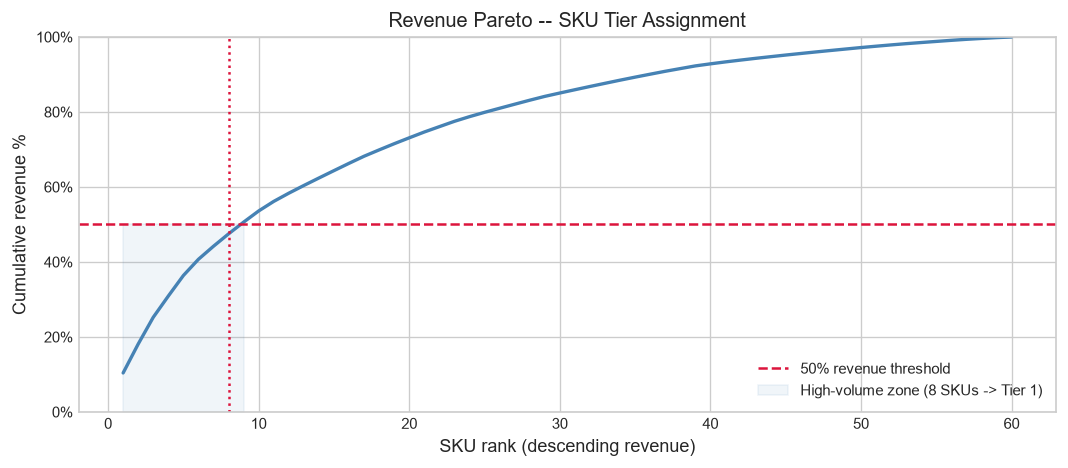

In [11]:
# Revenue segmentation -- exact logic from train/train.py
HIGH_VOLUME_REVENUE_THRESHOLD = 50.0  # % of total revenue

df["revenue"] = df["unit_price_eur"] * df["units_sold"]
sku_revenue = (
    df.groupby("product_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
sku_revenue["cum_pct"] = sku_revenue["revenue"].cumsum() / sku_revenue["revenue"].sum() * 100

high_volume = set(
    sku_revenue[sku_revenue["cum_pct"] <= HIGH_VOLUME_REVENUE_THRESHOLD]["product_id"]
)
high_volume.add(sku_revenue.iloc[0]["product_id"])  # always include top SKU
mid_volume = set(sku_revenue["product_id"]) - high_volume

print(f"Total SKUs     : {df['product_id'].nunique()}")
print(f"High-volume    : {len(high_volume)} SKUs (top {HIGH_VOLUME_REVENUE_THRESHOLD:.0f}% revenue) -> Tier 1")
print(f"Mid-volume     : {len(mid_volume)} SKUs (remainder) -> Tier 2")
print()
hv_rev = sku_revenue[sku_revenue["product_id"].isin(high_volume)]["revenue"].sum()
total_rev = sku_revenue["revenue"].sum()
print(f"High-volume SKUs account for {hv_rev/total_rev*100:.1f}% of total revenue")

# Pareto curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(sku_revenue)+1), sku_revenue["cum_pct"], color="steelblue", lw=2)
ax.axhline(HIGH_VOLUME_REVENUE_THRESHOLD, color="crimson", lw=1.5, linestyle="--",
           label=f"{HIGH_VOLUME_REVENUE_THRESHOLD:.0f}% revenue threshold")

cutoff_rank = (sku_revenue["cum_pct"] <= HIGH_VOLUME_REVENUE_THRESHOLD).sum()
ax.axvline(cutoff_rank, color="crimson", lw=1.5, linestyle=":")
ax.fill_between(range(1, cutoff_rank+2), 0, HIGH_VOLUME_REVENUE_THRESHOLD,
                alpha=0.08, color="steelblue",
                label=f"High-volume zone ({len(high_volume)} SKUs -> Tier 1)")

ax.set_xlabel("SKU rank (descending revenue)")
ax.set_ylabel("Cumulative revenue %")
ax.set_title("Revenue Pareto -- SKU Tier Assignment")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
# train_dedicated -- exact copy from train/train.py
def train_dedicated(daily: pd.DataFrame, unit_cost: float) -> dict:
    """OLS on one SKU/market. Raises ValueError if data is insufficient."""
    weekly = weekly_aggregate(daily)
    weekly = weekly[weekly["units"] > 0]

    if len(weekly) < 8 or weekly["avg_price"].round(2).nunique() < 3:
        raise ValueError("Insufficient data for dedicated model.")

    X = design_matrix(weekly)
    y = np.log(weekly["units"].to_numpy())
    model = LinearRegression().fit(X, y)

    return {
        "model": model,
        "controls_mean": X[:, 1:].mean(axis=0),
        "min_price": float(weekly["avg_price"].min()),
        "max_price": float(weekly["avg_price"].max()),
        "unit_cost": unit_cost,
        "elasticity": float(model.coef_[0]),
        "r_squared": float(model.score(X, y)),
        "n_weeks": len(weekly),
        "model_tier": "dedicated",
    }


markets = sorted(df["market"].unique())
tier1_results = []
tier1_skipped = 0

for pid in sorted(high_volume):
    for mkt in markets:
        daily = df[(df["product_id"] == pid) & (df["market"] == mkt)].copy()
        if daily.empty:
            tier1_skipped += 1
            continue
        cost = float(daily["unit_cost_eur"].iloc[0])
        try:
            bundle = train_dedicated(daily, cost)
            tier1_results.append({
                "product_id": pid, "market": mkt,
                "elasticity": bundle["elasticity"],
                "r_squared": bundle["r_squared"],
                "n_weeks": bundle["n_weeks"],
                "bundle": bundle,
            })
        except ValueError:
            tier1_skipped += 1

tier1_df = pd.DataFrame([{k: v for k, v in r.items() if k != "bundle"} for r in tier1_results])

print(f"Tier 1 fitted  : {len(tier1_results)}")
print(f"Tier 1 skipped : {tier1_skipped}")
print()
if not tier1_df.empty:
    print("Tier 1 model statistics:")
    print(tier1_df[["elasticity", "r_squared", "n_weeks"]].describe().to_string())


Tier 1 fitted  : 24
Tier 1 skipped : 0

Tier 1 model statistics:
       elasticity  r_squared  n_weeks
count     24.0000    24.0000  24.0000
mean      -2.0006     0.6272 104.9583
std        0.4694     0.1170   0.2041
min       -2.9682     0.4287 104.0000
25%       -2.2505     0.5501 105.0000
50%       -2.0175     0.6169 105.0000
75%       -1.7201     0.7214 105.0000
max       -0.9057     0.8250 105.0000


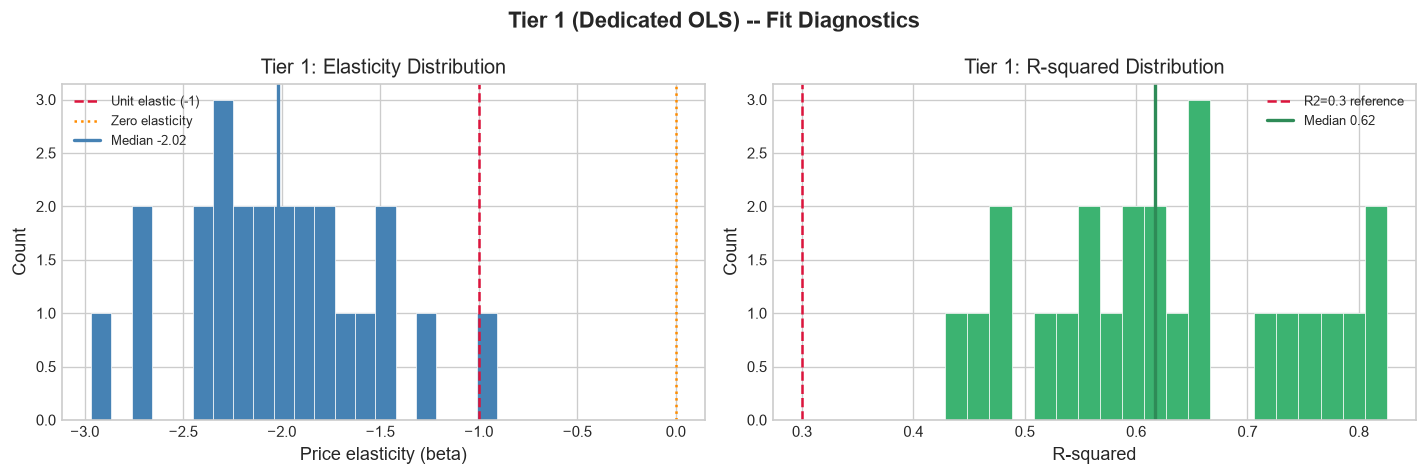

Models with R2 >= 0.3 : 24 (100.0%)
Models with R2 < 0.3  : 0 (0.0%)

Note: For a log-log weekly demand model with limited price variation,
R2~0.3 is common and often actionable. The key question is whether the
sign and magnitude of beta is economically plausible -- not maximising R2.


In [13]:
# Tier 1 diagnostics: elasticity and R^2 distributions
if not tier1_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.hist(tier1_df["elasticity"], bins=20, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.axvline(-1, color="crimson", lw=1.5, linestyle="--", label="Unit elastic (-1)")
    ax.axvline(0, color="darkorange", lw=1.5, linestyle=":", label="Zero elasticity")
    ax.axvline(tier1_df["elasticity"].median(), color="steelblue", lw=2, linestyle="-",
               label=f"Median {tier1_df['elasticity'].median():.2f}")
    ax.set_xlabel("Price elasticity (beta)")
    ax.set_ylabel("Count")
    ax.set_title("Tier 1: Elasticity Distribution")
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.hist(tier1_df["r_squared"], bins=20, color="mediumseagreen", edgecolor="white", linewidth=0.4)
    ax.axvline(0.3, color="crimson", lw=1.5, linestyle="--", label="R2=0.3 reference")
    ax.axvline(tier1_df["r_squared"].median(), color="seagreen", lw=2, linestyle="-",
               label=f"Median {tier1_df['r_squared'].median():.2f}")
    ax.set_xlabel("R-squared")
    ax.set_ylabel("Count")
    ax.set_title("Tier 1: R-squared Distribution")
    ax.legend(fontsize=8)

    plt.suptitle("Tier 1 (Dedicated OLS) -- Fit Diagnostics", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    r2_above = (tier1_df["r_squared"] >= 0.3).sum()
    r2_below = (tier1_df["r_squared"] < 0.3).sum()
    print(f"Models with R2 >= 0.3 : {r2_above} ({r2_above/len(tier1_df)*100:.1f}%)")
    print(f"Models with R2 < 0.3  : {r2_below} ({r2_below/len(tier1_df)*100:.1f}%)")
    print()
    print("Note: For a log-log weekly demand model with limited price variation,")
    print("R2~0.3 is common and often actionable. The key question is whether the")
    print("sign and magnitude of beta is economically plausible -- not maximising R2.")
else:
    print("No Tier 1 models fitted.")


Best Tier 1 model: SKU=SKU-1044, Market=DE
  R2=0.825, elasticity=-1.733, n_weeks=105


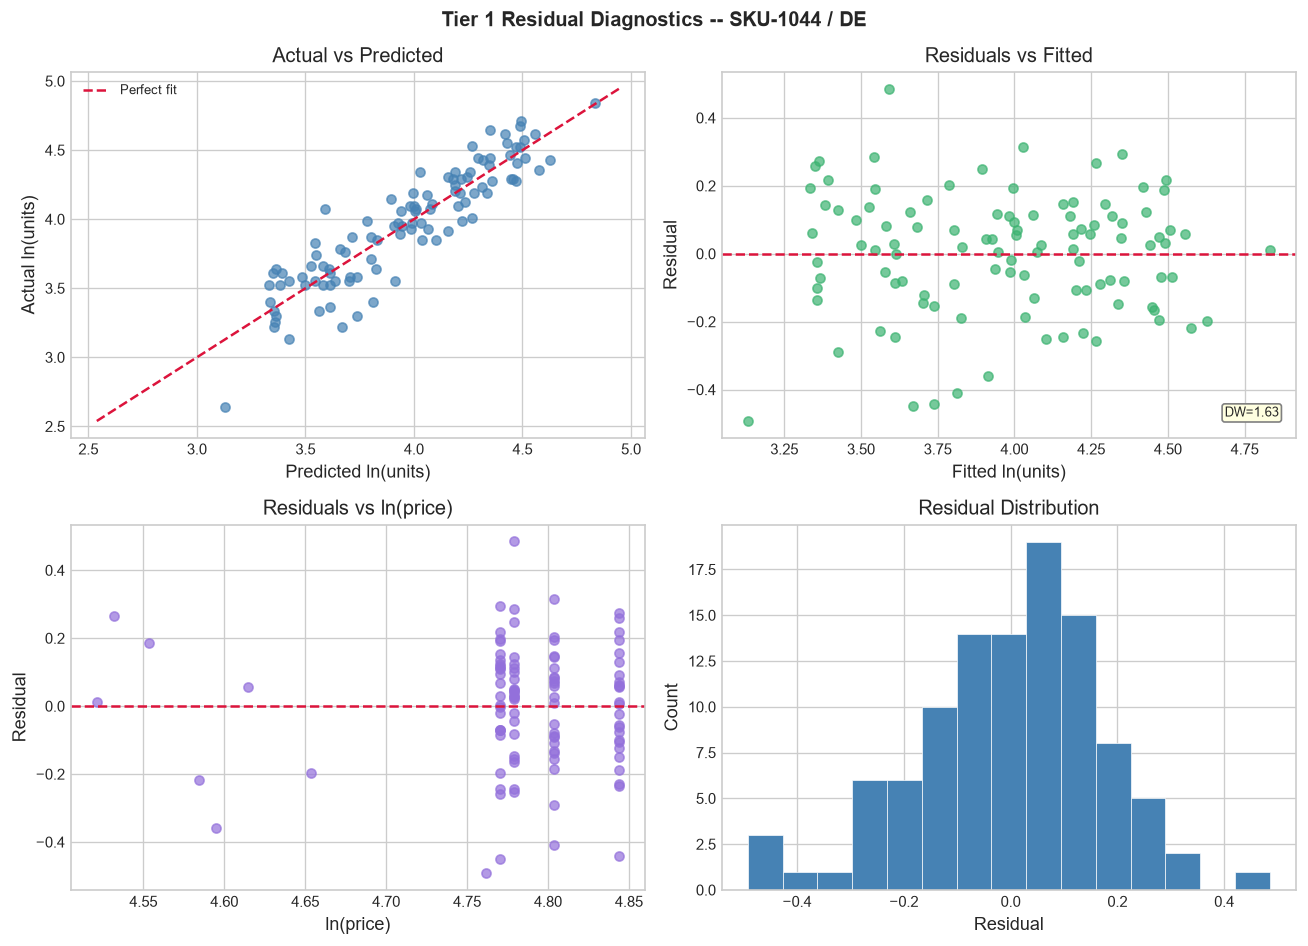

Durbin-Watson: 1.627
  Interpretation: no autocorrelation (DW~2 is ideal; range 0-4)


In [14]:
# Residual analysis for best-R2 Tier 1 model
if not tier1_df.empty:
    best_idx = tier1_df["r_squared"].idxmax()
    best_row = tier1_df.loc[best_idx]
    best_bundle = tier1_results[best_idx]["bundle"]
    best_pid, best_mkt = best_row["product_id"], best_row["market"]

    print(f"Best Tier 1 model: SKU={best_pid}, Market={best_mkt}")
    print(f"  R2={best_row['r_squared']:.3f}, elasticity={best_row['elasticity']:.3f}, n_weeks={best_row['n_weeks']}")

    daily_best = df[(df["product_id"] == best_pid) & (df["market"] == best_mkt)].copy()
    weekly_best = weekly_aggregate(daily_best)
    weekly_best = weekly_best[weekly_best["units"] > 0]
    X_best = design_matrix(weekly_best)
    y_best = np.log(weekly_best["units"].to_numpy())
    model_best = best_bundle["model"]
    y_pred = model_best.predict(X_best)
    residuals = y_best - y_pred

    # Durbin-Watson statistic (manual)
    dw = np.sum(np.diff(residuals)**2) / np.sum(residuals**2)

    fig, axes = plt.subplots(2, 2, figsize=(11, 8))

    ax = axes[0, 0]
    ax.scatter(y_pred, y_best, alpha=0.7, color="steelblue", s=30)
    lims = [min(y_pred.min(), y_best.min()) - 0.1, max(y_pred.max(), y_best.max()) + 0.1]
    ax.plot(lims, lims, "--", color="crimson", lw=1.5, label="Perfect fit")
    ax.set_xlabel("Predicted ln(units)")
    ax.set_ylabel("Actual ln(units)")
    ax.set_title("Actual vs Predicted")
    ax.legend(fontsize=8)

    ax = axes[0, 1]
    ax.scatter(y_pred, residuals, alpha=0.7, color="mediumseagreen", s=30)
    ax.axhline(0, color="crimson", lw=1.5, linestyle="--")
    ax.set_xlabel("Fitted ln(units)")
    ax.set_ylabel("Residual")
    ax.set_title("Residuals vs Fitted")
    ax.text(0.97, 0.05, f"DW={dw:.2f}", transform=ax.transAxes, ha="right", va="bottom",
            fontsize=8, bbox=dict(boxstyle="round,pad=0.2", fc="lightyellow", ec="gray"))

    ax = axes[1, 0]
    ax.scatter(X_best[:, 0], residuals, alpha=0.7, color="mediumpurple", s=30)
    ax.axhline(0, color="crimson", lw=1.5, linestyle="--")
    ax.set_xlabel("ln(price)")
    ax.set_ylabel("Residual")
    ax.set_title("Residuals vs ln(price)")

    ax = axes[1, 1]
    ax.hist(residuals, bins=15, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")
    ax.set_title("Residual Distribution")

    plt.suptitle(f"Tier 1 Residual Diagnostics -- {best_pid} / {best_mkt}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"Durbin-Watson: {dw:.3f}")
    dw_interp = "no autocorrelation" if 1.5 < dw < 2.5 else (
        "positive autocorrelation" if dw < 1.5 else "negative autocorrelation"
    )
    print(f"  Interpretation: {dw_interp} (DW~2 is ideal; range 0-4)")
else:
    print("No Tier 1 models to diagnose.")


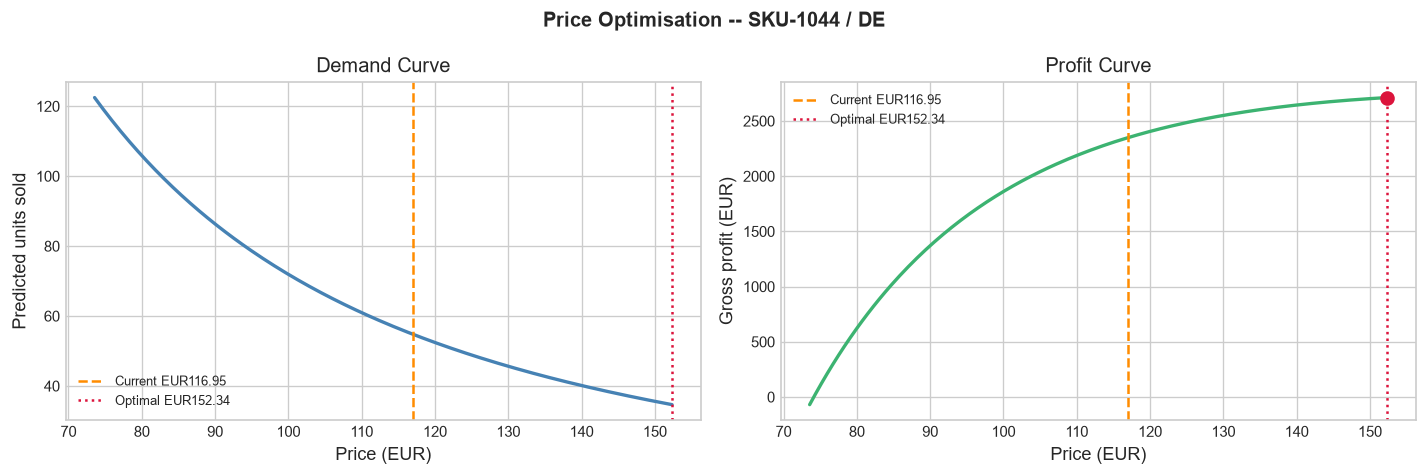

Current price  : EUR116.95
Optimal price  : EUR152.34
Profit uplift  : +15.5%
Elasticity     : -1.733


In [15]:
# Profit curve for the best-R2 Tier 1 model
if not tier1_df.empty:
    unit_cost_best = best_bundle["unit_cost"]
    min_p = best_bundle["min_price"]
    max_p = best_bundle["max_price"]
    controls_mean = best_bundle["controls_mean"]

    price_grid = np.linspace(min_p * 0.8, max_p * 1.2, 200)
    X_curve = np.column_stack([
        np.log(price_grid),
        np.tile(controls_mean, (len(price_grid), 1)),
    ])
    ln_units_pred = model_best.predict(X_curve)
    units_pred = np.exp(ln_units_pred)
    profit = (price_grid - unit_cost_best) * units_pred

    opt_idx = np.argmax(profit)
    opt_price = price_grid[opt_idx]
    opt_profit = profit[opt_idx]

    current_price = weekly_best["avg_price"].iloc[-1]
    curr_X = np.column_stack([
        np.log(np.array([current_price])),
        controls_mean.reshape(1, -1),
    ])
    curr_units = np.exp(model_best.predict(curr_X))[0]
    curr_profit = (current_price - unit_cost_best) * curr_units
    profit_uplift = (opt_profit - curr_profit) / max(curr_profit, 1e-9) * 100

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.plot(price_grid, units_pred, color="steelblue", lw=2)
    ax.axvline(current_price, color="darkorange", lw=1.5, linestyle="--",
               label=f"Current EUR{current_price:.2f}")
    ax.axvline(opt_price, color="crimson", lw=1.5, linestyle=":",
               label=f"Optimal EUR{opt_price:.2f}")
    ax.set_xlabel("Price (EUR)")
    ax.set_ylabel("Predicted units sold")
    ax.set_title("Demand Curve")
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.plot(price_grid, profit, color="mediumseagreen", lw=2)
    ax.axvline(current_price, color="darkorange", lw=1.5, linestyle="--",
               label=f"Current EUR{current_price:.2f}")
    ax.axvline(opt_price, color="crimson", lw=1.5, linestyle=":",
               label=f"Optimal EUR{opt_price:.2f}")
    ax.scatter([opt_price], [opt_profit], color="crimson", zorder=5, s=60)
    ax.set_xlabel("Price (EUR)")
    ax.set_ylabel("Gross profit (EUR)")
    ax.set_title("Profit Curve")
    ax.legend(fontsize=8)

    plt.suptitle(f"Price Optimisation -- {best_pid} / {best_mkt}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"Current price  : EUR{current_price:.2f}")
    print(f"Optimal price  : EUR{opt_price:.2f}")
    print(f"Profit uplift  : {profit_uplift:+.1f}%")
    print(f"Elasticity     : {best_row['elasticity']:.3f}")
else:
    print("No Tier 1 models available for profit curve.")


## 6. Tier 2 -- Category Ridge (Mid-Volume SKUs)


In [16]:
print(
    "Mid-volume SKUs have too few observations for stable OLS. We pool within "
    "category x market, letting all SKUs share a single price elasticity coefficient "
    "while each retaining its own intercept via SKU dummies. Ridge regularisation "
    "(alpha=1.0) shrinks the shared elasticity toward zero, preventing overfitting on "
    "categories with few SKUs."
)
print()
print(f"Mid-volume SKU count : {len(mid_volume)}")
print(f"Markets              : {markets}")
print(f"Categories           : {sorted(df['category'].unique())}")
print(f"Category x market combinations : {len(df['category'].unique()) * len(markets)}")


Mid-volume SKUs have too few observations for stable OLS. We pool within category x market, letting all SKUs share a single price elasticity coefficient while each retaining its own intercept via SKU dummies. Ridge regularisation (alpha=1.0) shrinks the shared elasticity toward zero, preventing overfitting on categories with few SKUs.

Mid-volume SKU count : 52
Markets              : ['CH', 'DE', 'FR']
Categories           : ['Ceiling Lights', 'Floor Lamps', 'Outdoor Lighting', 'Pendant Lights', 'Smart Lighting', 'Wall Lights']
Category x market combinations : 18


In [17]:
# build_category_dataset and train_category -- exact copies from train/train.py

def build_category_dataset(
    df_: pd.DataFrame, skus: set, category: str, market: str
) -> dict | None:
    """Stack weekly rows for all mid-volume SKUs in one category/market."""
    frames = []
    for pid in sorted(skus):
        grp = df_[
            (df_["product_id"] == pid)
            & (df_["market"] == market)
            & (df_["category"] == category)
        ].copy()
        if grp.empty:
            continue
        w = weekly_aggregate(grp)
        w = w[w["units"] > 0]
        if len(w) < 4:
            continue
        w["product_id"] = pid
        w["unit_cost"] = float(grp["unit_cost_eur"].iloc[0])
        frames.append(w)

    if not frames:
        return None

    combined = pd.concat(frames, ignore_index=True)
    X_base = design_matrix(combined)
    sku_dummies = pd.get_dummies(combined["product_id"], dtype=float, drop_first=True)
    X = np.column_stack([X_base, sku_dummies.to_numpy()])
    y = np.log(combined["units"].to_numpy())

    return {
        "X": X, "y": y,
        "price_ranges": {
            pid: (float(g["avg_price"].min()), float(g["avg_price"].max()))
            for pid, g in combined.groupby("product_id")
        },
        "unit_costs": combined.groupby("product_id")["unit_cost"].first().to_dict(),
        "controls_mean": X_base[:, 1:].mean(axis=0),
        "sku_columns": list(sku_dummies.columns),
        "n_base_features": X_base.shape[1],
    }


def train_category(data: dict, category: str, market: str) -> dict:
    ridge = Ridge(alpha=1.0).fit(data["X"], data["y"])
    cv_r2 = cross_val_score(
        Ridge(alpha=1.0), data["X"], data["y"],
        cv=min(5, len(data["y"]) // 4),
        scoring="r2",
    )
    return {
        "model": ridge,
        "controls_mean": data["controls_mean"],
        "price_ranges": data["price_ranges"],
        "unit_costs": data["unit_costs"],
        "sku_columns": data["sku_columns"],
        "n_base_features": data["n_base_features"],
        "elasticity": float(ridge.coef_[0]),
        "r_squared_train": float(ridge.score(data["X"], data["y"])),
        "r_squared_cv": float(cv_r2.mean()),
        "n_samples": len(data["y"]),
        "model_tier": "category",
        "category": category,
        "market": market,
    }


tier2_results = []
for cat in sorted(df["category"].unique()):
    for mkt in markets:
        data = build_category_dataset(df, mid_volume, cat, mkt)
        if data is None or len(data["y"]) < 10:
            continue
        bundle = train_category(data, cat, mkt)
        tier2_results.append({
            "category": cat, "market": mkt,
            "elasticity": bundle["elasticity"],
            "r_squared_train": bundle["r_squared_train"],
            "r_squared_cv": bundle["r_squared_cv"],
            "n_samples": bundle["n_samples"],
        })

tier2_df = pd.DataFrame(tier2_results)
print(f"Tier 2 models fitted: {len(tier2_results)}")
print()
if not tier2_df.empty:
    print(tier2_df[["category", "market", "elasticity", "r_squared_train", "r_squared_cv", "n_samples"]].to_string(index=False))


Tier 2 models fitted: 18

        category market  elasticity  r_squared_train  r_squared_cv  n_samples
  Ceiling Lights     CH     -0.9207           0.6706       -0.5458       1003
  Ceiling Lights     DE     -1.0044           0.8477       -3.1537       1050
  Ceiling Lights     FR     -0.9942           0.7871       -1.0567       1041
     Floor Lamps     CH     -1.2410           0.5729        0.1796        799
     Floor Lamps     DE     -1.7830           0.8243       -1.5745        935
     Floor Lamps     FR     -1.4943           0.7468       -0.3653        875
Outdoor Lighting     CH     -1.1459           0.5952        0.1481        638
Outdoor Lighting     DE     -1.3270           0.8396        0.3498        731
Outdoor Lighting     FR     -1.0106           0.7406        0.2242        693
  Pendant Lights     CH     -0.4305           0.2050       -0.2060        658
  Pendant Lights     DE     -0.9066           0.5960        0.0495        812
  Pendant Lights     FR     -0.3509   

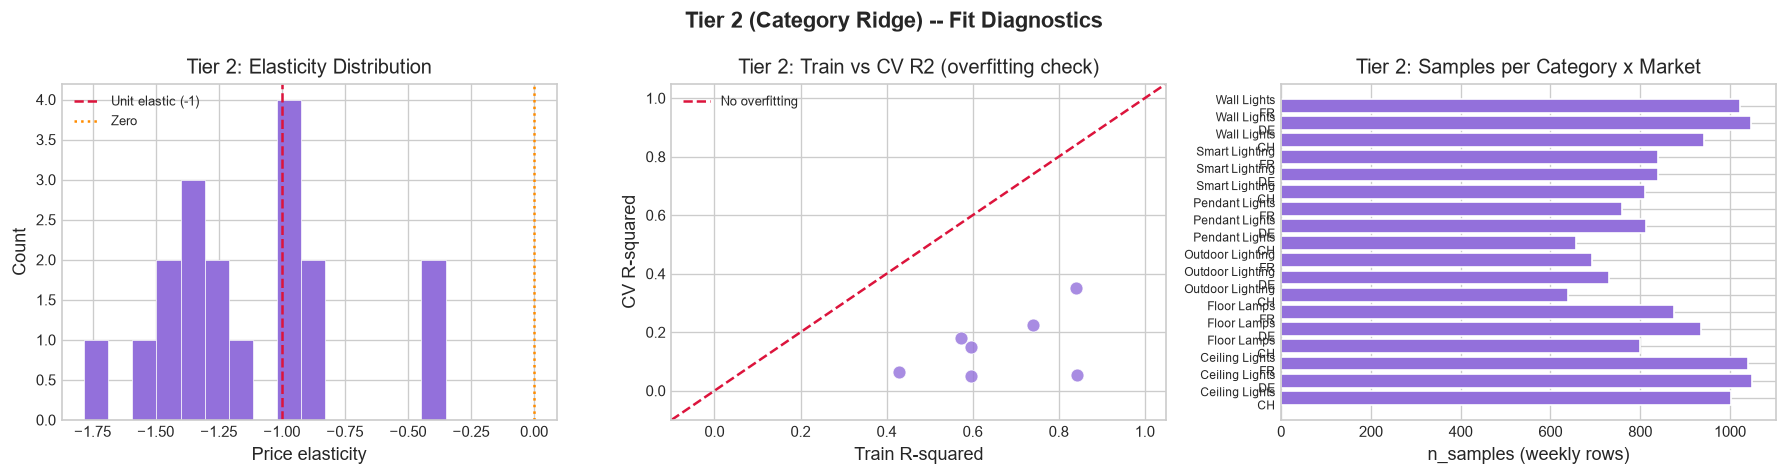

Mean overfitting gap (train - CV R2): 1.495
Ridge regularisation shrinks this gap versus unregularised OLS.
High-overfitting groups (gap > 0.2): 18
        category market  n_samples  r_squared_train  r_squared_cv
  Ceiling Lights     CH       1003           0.6706       -0.5458
  Ceiling Lights     DE       1050           0.8477       -3.1537
  Ceiling Lights     FR       1041           0.7871       -1.0567
     Floor Lamps     CH        799           0.5729        0.1796
     Floor Lamps     DE        935           0.8243       -1.5745
     Floor Lamps     FR        875           0.7468       -0.3653
Outdoor Lighting     CH        638           0.5952        0.1481
Outdoor Lighting     DE        731           0.8396        0.3498
Outdoor Lighting     FR        693           0.7406        0.2242
  Pendant Lights     CH        658           0.2050       -0.2060
  Pendant Lights     DE        812           0.5960        0.0495
  Pendant Lights     FR        759           0.4288        0

In [18]:
# Tier 2 diagnostics
if not tier2_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    ax = axes[0]
    ax.hist(tier2_df["elasticity"], bins=15, color="mediumpurple", edgecolor="white", linewidth=0.4)
    ax.axvline(-1, color="crimson", lw=1.5, linestyle="--", label="Unit elastic (-1)")
    ax.axvline(0, color="darkorange", lw=1.5, linestyle=":", label="Zero")
    ax.set_xlabel("Price elasticity")
    ax.set_ylabel("Count")
    ax.set_title("Tier 2: Elasticity Distribution")
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.scatter(tier2_df["r_squared_train"], tier2_df["r_squared_cv"],
               color="mediumpurple", alpha=0.8, s=60, edgecolors="white", linewidths=0.5)
    lims = [-0.1, 1.05]
    ax.plot(lims, lims, "--", color="crimson", lw=1.5, label="No overfitting")
    ax.set_xlabel("Train R-squared")
    ax.set_ylabel("CV R-squared")
    ax.set_title("Tier 2: Train vs CV R2 (overfitting check)")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.legend(fontsize=8)

    ax = axes[2]
    labels = tier2_df["category"] + "\n" + tier2_df["market"]
    ax.barh(range(len(tier2_df)), tier2_df["n_samples"], color="mediumpurple", edgecolor="white")
    ax.set_yticks(range(len(tier2_df)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("n_samples (weekly rows)")
    ax.set_title("Tier 2: Samples per Category x Market")

    plt.suptitle("Tier 2 (Category Ridge) -- Fit Diagnostics", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    overfit_gap = (tier2_df["r_squared_train"] - tier2_df["r_squared_cv"]).mean()
    print(f"Mean overfitting gap (train - CV R2): {overfit_gap:.3f}")
    print("Ridge regularisation shrinks this gap versus unregularised OLS.")
    high_overfit = tier2_df[tier2_df["r_squared_train"] - tier2_df["r_squared_cv"] > 0.2]
    if not high_overfit.empty:
        print(f"High-overfitting groups (gap > 0.2): {len(high_overfit)}")
        print(high_overfit[["category", "market", "n_samples", "r_squared_train", "r_squared_cv"]].to_string(index=False))
else:
    print("No Tier 2 models fitted.")


## 7. Tier 3 -- Global RidgeCV


In [19]:
# build_global_dataset and train_global -- exact copies from train/train.py

def build_global_dataset(df_: pd.DataFrame) -> dict:
    """Pool every SKU x market x category into one training table."""
    frames = []
    for (pid, mkt, cat), grp in df_.groupby(["product_id", "market", "category"]):
        w = weekly_aggregate(grp.copy())
        w = w[w["units"] > 0]
        if len(w) < 4:
            continue
        w["product_id"] = pid
        w["market"] = mkt
        w["category"] = cat
        w["unit_cost"] = float(grp["unit_cost_eur"].iloc[0])
        frames.append(w)

    combined = pd.concat(frames, ignore_index=True)
    X_base = design_matrix(combined)
    prod_dummies = pd.get_dummies(combined["product_id"], dtype=float, drop_first=True)
    mkt_dummies = pd.get_dummies(combined["market"], dtype=float, drop_first=True)
    cat_dummies = pd.get_dummies(combined["category"], dtype=float, drop_first=True)
    X = np.column_stack([
        X_base, prod_dummies.to_numpy(),
        mkt_dummies.to_numpy(), cat_dummies.to_numpy(),
    ])
    y = np.log(combined["units"].to_numpy())
    return {
        "X": X, "y": y,
        "X_base_n_features": X_base.shape[1],
        "controls_mean": X_base[:, 1:].mean(axis=0),
        "prod_columns": list(prod_dummies.columns),
        "mkt_columns": list(mkt_dummies.columns),
        "cat_columns": list(cat_dummies.columns),
    }


def train_global(data: dict) -> dict:
    alphas = np.logspace(-2, 4, 50)
    model = RidgeCV(alphas=alphas, cv=5, scoring="r2").fit(data["X"], data["y"])
    cv_r2 = cross_val_score(
        Ridge(alpha=float(model.alpha_)), data["X"], data["y"], cv=5, scoring="r2"
    )
    return {
        "model": model,
        "elasticity": float(model.coef_[0]),
        "r_squared_train": float(model.score(data["X"], data["y"])),
        "r_squared_cv": float(cv_r2.mean()),
        "alpha": float(model.alpha_),
        "controls_mean": data["controls_mean"],
        "prod_columns": data["prod_columns"],
        "mkt_columns": data["mkt_columns"],
        "cat_columns": data["cat_columns"],
        "n_base_features": data["X_base_n_features"],
        "n_samples": len(data["y"]),
        "model_tier": "global",
    }


global_data = build_global_dataset(df)
global_bundle = train_global(global_data)

print("Global RidgeCV results:")
print(f"  Best alpha       : {global_bundle['alpha']:.4f}")
print(f"  Elasticity       : {global_bundle['elasticity']:.4f}")
print(f"  Train R-squared  : {global_bundle['r_squared_train']:.4f}")
print(f"  CV R-squared     : {global_bundle['r_squared_cv']:.4f}")
print(f"  n_samples        : {global_bundle['n_samples']:,}")
print(f"  n_features total : {global_data['X'].shape[1]}")
print(f"    base features  : {global_bundle['n_base_features']} (ln_price, ln_ads, 11 month dummies)")
print(f"    product dummies: {len(global_bundle['prod_columns'])}")
print(f"    market dummies : {len(global_bundle['mkt_columns'])}")
print(f"    category dummies: {len(global_bundle['cat_columns'])}")


Global RidgeCV results:
  Best alpha       : 790.6043
  Elasticity       : -0.2957
  Train R-squared  : 0.5473
  CV R-squared     : 0.1742
  n_samples        : 18,011
  n_features total : 79
    base features  : 13 (ln_price, ln_ads, 11 month dummies)
    product dummies: 59
    market dummies : 2
    category dummies: 5


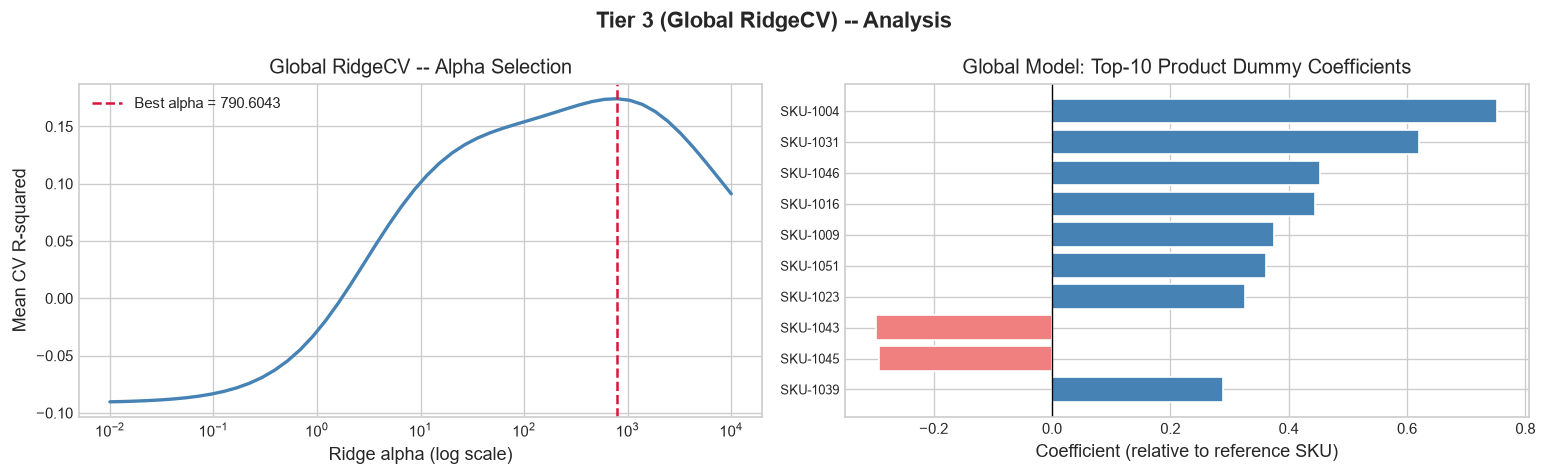

Top-5 market dummy coefficients:
DE   0.9928
FR   0.2558

Top-5 category dummy coefficients:
Smart Lighting      0.2066
Wall Lights        -0.1664
Pendant Lights     -0.1312
Outdoor Lighting    0.0382
Floor Lamps        -0.0246

Note: The global elasticity is a population prior -- it stabilises inference
for data-sparse segments that fall through Tier 1 and Tier 2.


In [20]:
# Alpha selection plot + coefficient analysis
alphas_grid = np.logspace(-2, 4, 50)
cv_scores_by_alpha = []
for a in alphas_grid:
    scores = cross_val_score(
        Ridge(alpha=a), global_data["X"], global_data["y"], cv=5, scoring="r2"
    )
    cv_scores_by_alpha.append(scores.mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.semilogx(alphas_grid, cv_scores_by_alpha, color="steelblue", lw=2)
ax.axvline(global_bundle["alpha"], color="crimson", lw=1.5, linestyle="--",
           label=f"Best alpha = {global_bundle['alpha']:.4f}")
ax.set_xlabel("Ridge alpha (log scale)")
ax.set_ylabel("Mean CV R-squared")
ax.set_title("Global RidgeCV -- Alpha Selection")
ax.legend()

# Top-10 product coefficients by absolute magnitude
n_base = global_bundle["n_base_features"]
n_prod = len(global_bundle["prod_columns"])
n_mkt = len(global_bundle["mkt_columns"])
n_cat = len(global_bundle["cat_columns"])

prod_coefs_signed = pd.Series(
    global_bundle["model"].coef_[n_base:n_base+n_prod],
    index=global_bundle["prod_columns"]
)
top10 = prod_coefs_signed.abs().sort_values(ascending=False).head(10).index
prod_coefs_top = prod_coefs_signed.reindex(top10)

ax = axes[1]
colors_bar = ["steelblue" if v > 0 else "lightcoral" for v in prod_coefs_top.values]
ax.barh(range(len(prod_coefs_top)), prod_coefs_top.values[::-1], color=colors_bar[::-1], edgecolor="white")
ax.set_yticks(range(len(prod_coefs_top)))
ax.set_yticklabels(prod_coefs_top.index[::-1], fontsize=8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coefficient (relative to reference SKU)")
ax.set_title("Global Model: Top-10 Product Dummy Coefficients")

plt.suptitle("Tier 3 (Global RidgeCV) -- Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top-5 market dummy coefficients:")
mkt_coefs = pd.Series(
    global_bundle["model"].coef_[n_base+n_prod:n_base+n_prod+n_mkt],
    index=global_bundle["mkt_columns"]
).sort_values(key=abs, ascending=False).head(5)
print(mkt_coefs.to_string())
print()
print("Top-5 category dummy coefficients:")
cat_coefs = pd.Series(
    global_bundle["model"].coef_[n_base+n_prod+n_mkt:n_base+n_prod+n_mkt+n_cat],
    index=global_bundle["cat_columns"]
).sort_values(key=abs, ascending=False).head(5)
print(cat_coefs.to_string())
print()
print("Note: The global elasticity is a population prior -- it stabilises inference")
print("for data-sparse segments that fall through Tier 1 and Tier 2.")


## 8. Cross-Tier Comparison


In [21]:
# Build a unified comparison DataFrame across all three tiers
comparison_rows = []

for r in tier1_results:
    comparison_rows.append({
        "tier": "Tier 1 (Dedicated OLS)",
        "elasticity": r["elasticity"],
        "r2_train": r["r_squared"],
        "r2_cv": np.nan,
        "n_samples": r["n_weeks"],
    })

for r in tier2_results:
    comparison_rows.append({
        "tier": "Tier 2 (Category Ridge)",
        "elasticity": r["elasticity"],
        "r2_train": r["r_squared_train"],
        "r2_cv": r["r_squared_cv"],
        "n_samples": r["n_samples"],
    })

comparison_rows.append({
    "tier": "Tier 3 (Global Ridge)",
    "elasticity": global_bundle["elasticity"],
    "r2_train": global_bundle["r_squared_train"],
    "r2_cv": global_bundle["r_squared_cv"],
    "n_samples": global_bundle["n_samples"],
})

comp_df = pd.DataFrame(comparison_rows)

print("Cross-tier summary:")
print(comp_df.groupby("tier")[["elasticity", "r2_train", "r2_cv"]].describe().round(3).to_string())
print()
print("Median elasticity by tier:")
print(comp_df.groupby("tier")["elasticity"].median().to_string())


Cross-tier summary:
                        elasticity                                                        r2_train                                                    r2_cv                                                     
                             count    mean    std     min     25%     50%     75%     max    count   mean    std    min    25%    50%    75%    max   count    mean    std     min     25%     50%    75%    max
tier                                                                                                                                                                                                            
Tier 1 (Dedicated OLS)     24.0000 -2.0010 0.4690 -2.9680 -2.2510 -2.0180 -1.7200 -0.9060  24.0000 0.6270 0.1170 0.4290 0.5500 0.6170 0.7210 0.8250  0.0000     NaN    NaN     NaN     NaN     NaN    NaN    NaN
Tier 2 (Category Ridge)    18.0000 -1.1430 0.3660 -1.7830 -1.3790 -1.1930 -0.9950 -0.3510  18.0000 0.6780 0.1800 0.2050 0.5950 0.7200 0.8240 0.8

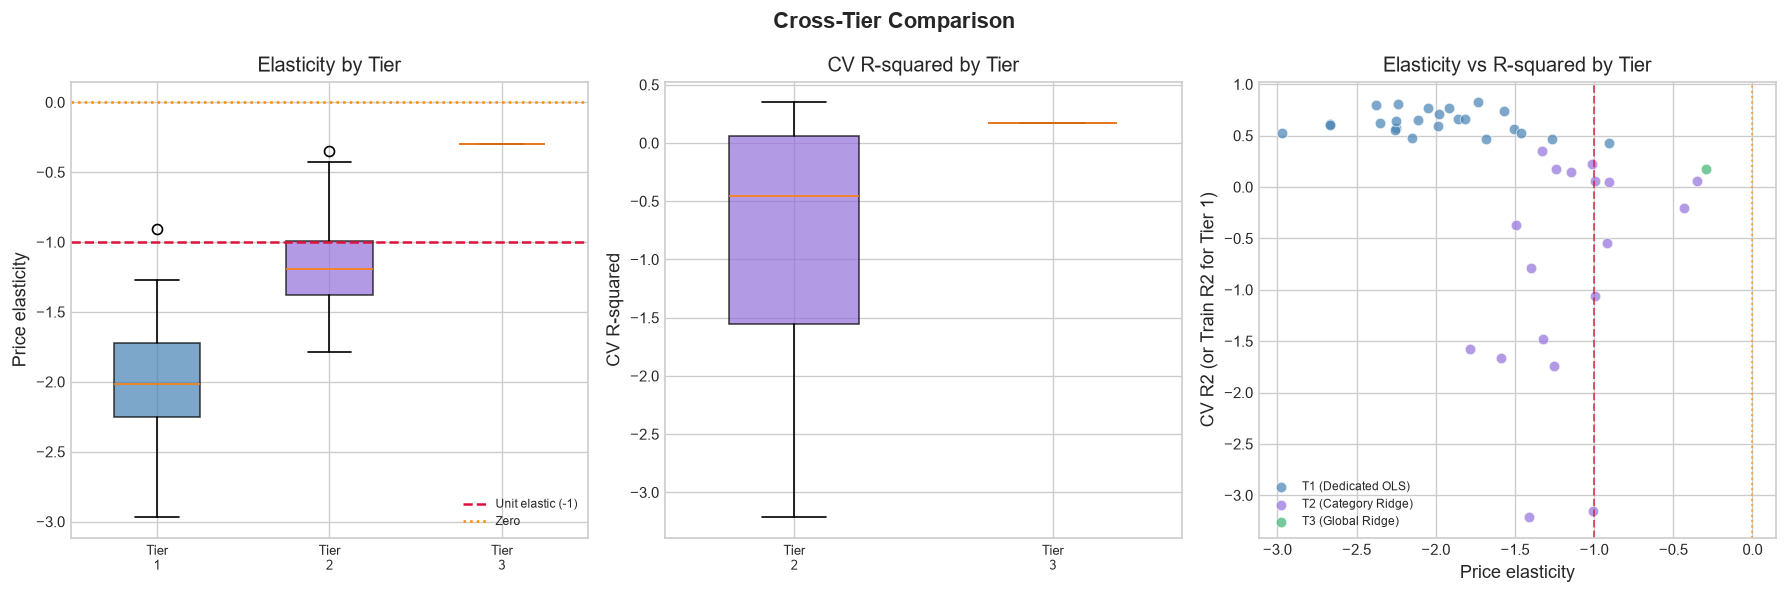

In [22]:
tier_palette = {
    "Tier 1 (Dedicated OLS)": "steelblue",
    "Tier 2 (Category Ridge)": "mediumpurple",
    "Tier 3 (Global Ridge)": "mediumseagreen",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
tiers_order = list(tier_palette.keys())

# Panel 1: elasticity box plot by tier
ax = axes[0]
data_by_tier = [comp_df[comp_df["tier"] == t]["elasticity"].dropna().values for t in tiers_order]
data_by_tier_nonempty = [(d, t) for d, t in zip(data_by_tier, tiers_order) if len(d) > 0]
if data_by_tier_nonempty:
    bp = ax.boxplot([d for d, _ in data_by_tier_nonempty], patch_artist=True, widths=0.5)
    for patch, (_, t) in zip(bp["boxes"], data_by_tier_nonempty):
        patch.set_facecolor(tier_palette[t])
        patch.set_alpha(0.7)
    ax.set_xticklabels([t.split(" ")[0]+"\n"+t.split(" ")[1] for _, t in data_by_tier_nonempty], fontsize=8)
ax.axhline(-1, color="crimson", lw=1.5, linestyle="--", label="Unit elastic (-1)")
ax.axhline(0, color="darkorange", lw=1.5, linestyle=":", label="Zero")
ax.set_ylabel("Price elasticity")
ax.set_title("Elasticity by Tier")
ax.legend(fontsize=7)

# Panel 2: CV R2 box plot by tier (Tiers 2+3 have CV)
ax = axes[1]
r2cv_nonempty = [(comp_df[comp_df["tier"]==t]["r2_cv"].dropna().values, t)
                 for t in tiers_order if comp_df[comp_df["tier"]==t]["r2_cv"].notna().any()]
if r2cv_nonempty:
    bp2 = ax.boxplot([d for d, _ in r2cv_nonempty], patch_artist=True, widths=0.5)
    for patch, (_, t) in zip(bp2["boxes"], r2cv_nonempty):
        patch.set_facecolor(tier_palette[t])
        patch.set_alpha(0.7)
    ax.set_xticklabels([t.split(" ")[0]+"\n"+t.split(" ")[1] for _, t in r2cv_nonempty], fontsize=8)
ax.set_ylabel("CV R-squared")
ax.set_title("CV R-squared by Tier")

# Panel 3: elasticity vs R2 scatter
ax = axes[2]
for t, color in tier_palette.items():
    sub = comp_df[comp_df["tier"] == t]
    r2_col = "r2_cv" if sub["r2_cv"].notna().any() else "r2_train"
    ax.scatter(sub["elasticity"], sub[r2_col], color=color, alpha=0.7,
               label=t.replace("Tier ", "T"), s=40, edgecolors="white", linewidths=0.5)
ax.axvline(-1, color="crimson", lw=1.2, linestyle="--", alpha=0.7)
ax.axvline(0, color="darkorange", lw=1.2, linestyle=":", alpha=0.7)
ax.set_xlabel("Price elasticity")
ax.set_ylabel("CV R2 (or Train R2 for Tier 1)")
ax.set_title("Elasticity vs R-squared by Tier")
ax.legend(fontsize=7)

plt.suptitle("Cross-Tier Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


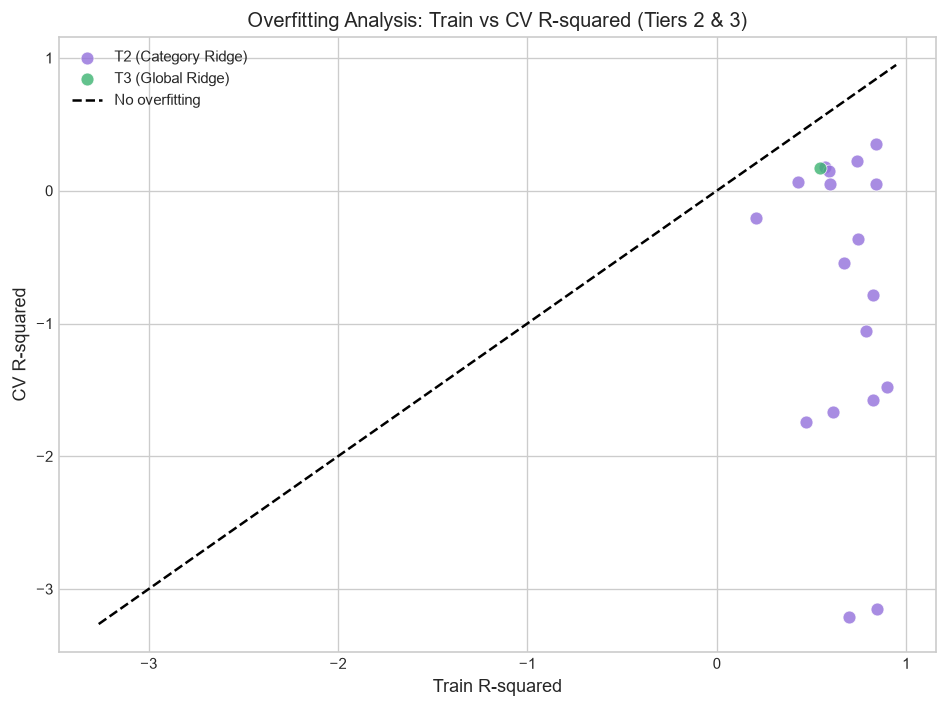

Mean overfitting gap (train R2 - CV R2) per tier:
tier
Tier 2 (Category Ridge)   1.4952
Tier 3 (Global Ridge)     0.3731

Ridge regularisation (Tier 2, 3) reduces overfitting vs unregularised OLS.
Points near the diagonal indicate CV R2 is a reliable generalisation estimate.


In [23]:
# Overfitting analysis: train R2 vs CV R2 for Tiers 2 and 3
overfit_rows = comp_df[comp_df["r2_cv"].notna()].copy()
overfit_rows["gap"] = overfit_rows["r2_train"] - overfit_rows["r2_cv"]

fig, ax = plt.subplots(figsize=(8, 6))

for t, color in tier_palette.items():
    sub = overfit_rows[overfit_rows["tier"] == t]
    if sub.empty:
        continue
    ax.scatter(sub["r2_train"], sub["r2_cv"], color=color, alpha=0.8,
               label=t.replace("Tier ", "T"), s=60, edgecolors="white", linewidths=0.5)

if not overfit_rows.empty:
    lims_min = min(overfit_rows["r2_train"].min(), overfit_rows["r2_cv"].min()) - 0.05
    lims_max = max(overfit_rows["r2_train"].max(), overfit_rows["r2_cv"].max()) + 0.05
    ax.plot([lims_min, lims_max], [lims_min, lims_max], "--", color="black", lw=1.5, label="No overfitting")

ax.set_xlabel("Train R-squared")
ax.set_ylabel("CV R-squared")
ax.set_title("Overfitting Analysis: Train vs CV R-squared (Tiers 2 & 3)")
ax.legend()
plt.tight_layout()
plt.show()

print("Mean overfitting gap (train R2 - CV R2) per tier:")
print(overfit_rows.groupby("tier")["gap"].mean().to_string())
print()
print("Ridge regularisation (Tier 2, 3) reduces overfitting vs unregularised OLS.")
print("Points near the diagonal indicate CV R2 is a reliable generalisation estimate.")


## 9. Key Findings & Decisions


In [24]:
# Structured findings summary
n_rows = len(df)
n_skus = df["product_id"].nunique()
n_markets = df["market"].nunique()
date_range_str = f"{df['date'].min().date()} -> {df['date'].max().date()}"

mean_prices = elig_df["n_distinct_prices"].mean()
pct_elig_t1 = elig_df["eligible"].mean() * 100

zero_by_mkt = df.groupby("market")["units_sold"].apply(lambda s: (s==0).mean()*100)

t1_count = len(tier1_df)
t1_mean_e = tier1_df["elasticity"].mean() if not tier1_df.empty else float("nan")
t1_mean_r2 = tier1_df["r_squared"].mean() if not tier1_df.empty else float("nan")
t1_pct_r2 = (tier1_df["r_squared"] >= 0.3).mean() * 100 if not tier1_df.empty else float("nan")

t2_count = len(tier2_df)
t2_mean_e = tier2_df["elasticity"].mean() if not tier2_df.empty else float("nan")
t2_mean_r2cv = tier2_df["r_squared_cv"].mean() if not tier2_df.empty else float("nan")

# Profit uplift for Tier 1 (midpoint price vs optimal)
uplift_pcts = []
for r in tier1_results:
    b = r["bundle"]
    try:
        p_grid = np.linspace(b["min_price"] * 0.8, b["max_price"] * 1.2, 200)
        X_c = np.column_stack([
            np.log(p_grid),
            np.tile(b["controls_mean"], (len(p_grid), 1)),
        ])
        u_pred = np.exp(b["model"].predict(X_c))
        profit_v = (p_grid - b["unit_cost"]) * u_pred
        opt_pr = profit_v.max()
        cur_p = (b["min_price"] + b["max_price"]) / 2
        X_cur = np.column_stack([np.log(np.array([cur_p])), b["controls_mean"].reshape(1, -1)])
        cur_u = np.exp(b["model"].predict(X_cur))[0]
        cur_pr = (cur_p - b["unit_cost"]) * cur_u
        if cur_pr > 0:
            uplift_pcts.append((opt_pr - cur_pr) / cur_pr * 100)
    except Exception:
        pass

mean_uplift = np.mean(uplift_pcts) if uplift_pcts else float("nan")
median_uplift = np.median(uplift_pcts) if uplift_pcts else float("nan")

all_elasticities = (
    list(tier1_df["elasticity"] if not tier1_df.empty else []) +
    list(tier2_df["elasticity"] if not tier2_df.empty else []) +
    [global_bundle["elasticity"]]
)

print("=" * 65)
print("PRICEPILOT -- EDA & MODELLING FINDINGS SUMMARY")
print("=" * 65)
print(f"Dataset        : {n_rows:,} rows | {n_skus} SKUs | {n_markets} markets | {date_range_str}")
print()
print("Price variation")
print(f"  Mean distinct prices per SKU x market : {mean_prices:.1f}")
print(f"  SKU x market pairs eligible for T1    : {pct_elig_t1:.1f}%")
print()
print("Zero-sales rates (daily)")
for mkt, rate in zero_by_mkt.items():
    print(f"  {mkt} : {rate:.1f}%")
print("  -> Motivates >=8 non-zero weeks threshold")
print()
print(f"Tier 1 (Dedicated OLS)")
print(f"  Models fitted  : {t1_count}")
print(f"  Mean elasticity: {t1_mean_e:.3f}")
print(f"  Mean R2        : {t1_mean_r2:.3f}")
print(f"  % with R2>=0.3 : {t1_pct_r2:.1f}%")
print()
print(f"Tier 2 (Category Ridge)")
print(f"  Models fitted  : {t2_count}")
print(f"  Mean elasticity: {t2_mean_e:.3f}")
print(f"  Mean CV R2     : {t2_mean_r2cv:.3f}")
print()
print(f"Tier 3 (Global Ridge)")
print(f"  Best alpha     : {global_bundle['alpha']:.4f}")
print(f"  Elasticity     : {global_bundle['elasticity']:.4f}")
print(f"  CV R2          : {global_bundle['r_squared_cv']:.4f}")
print()
print(f"Elasticity range (all tiers): [{min(all_elasticities):.2f}, {max(all_elasticities):.2f}]")
print(f"  -> Mostly elastic segments with some inelastic outliers")
print()
print(f"Profit uplift potential (Tier 1, midpoint price vs optimal):")
print(f"  Mean uplift  : {mean_uplift:.1f}%")
print(f"  Median uplift: {median_uplift:.1f}%")
print()
print("=" * 65)


PRICEPILOT -- EDA & MODELLING FINDINGS SUMMARY
Dataset        : 131,028 rows | 60 SKUs | 3 markets | 2024-01-01 -> 2025-12-31

Price variation
  Mean distinct prices per SKU x market : 11.5
  SKU x market pairs eligible for T1    : 100.0%

Zero-sales rates (daily)
  CH : 54.4%
  DE : 16.6%
  FR : 38.2%
  -> Motivates >=8 non-zero weeks threshold

Tier 1 (Dedicated OLS)
  Models fitted  : 24
  Mean elasticity: -2.001
  Mean R2        : 0.627
  % with R2>=0.3 : 100.0%

Tier 2 (Category Ridge)
  Models fitted  : 18
  Mean elasticity: -1.143
  Mean CV R2     : -0.818

Tier 3 (Global Ridge)
  Best alpha     : 790.6043
  Elasticity     : -0.2957
  CV R2          : 0.1742

Elasticity range (all tiers): [-2.97, -0.30]
  -> Mostly elastic segments with some inelastic outliers

Profit uplift potential (Tier 1, midpoint price vs optimal):
  Mean uplift  : 8.2%
  Median uplift: 1.4%



## Design Decisions & Rationale

| Decision | Choice | Rationale |
|---|---|---|
| Aggregation unit | Weekly | Reduces zero-inflation; removes day-of-week noise; still captures price changes |
| Log-log specification | ln(Q) = alpha + beta*ln(P) + ... | Constant elasticity; beta directly interpretable as % demand change per 1% price change |
| December as seasonal baseline | Dec omitted from month dummies | Highest-volume month; all other months interpreted relative to December |
| Tier 1 threshold | >=8 weeks AND >=3 distinct prices | Below this, OLS elasticity estimate has too wide a confidence interval to be actionable |
| Ridge alpha=1.0 for Tier 2 | Fixed, not cross-validated | Category groups are small (10-50 rows); CV on small groups is noisy; alpha=1.0 is a conservative default |
| Global RidgeCV alpha in [0.01, 10000] | Cross-validated over 50 alphas | Global model has 100+ features; optimal alpha cannot be guessed; CV is stable at this scale |
| Revenue-based tier assignment (50%) | Top-50% revenue -> Tier 1 | Prioritises modelling effort where it has highest business impact |
| ad_spend null fill = 0 | 0 -> ln(1) = 0 contribution | NaN means no campaign spend; imputing with mean would overstate advertising effect |


## Limitations

1. **Constant elasticity assumption**: the log-log model assumes elasticity is the same at all price levels. In practice, elasticity likely steepens above a threshold price. A piecewise or quadratic log-price specification could test this.

2. **No holdout evaluation**: models are evaluated with CV on in-distribution data. Temporal holdout (last 4 weeks as test set) would give a more honest view of generalisation.

3. **Price endogeneity**: price is partly set in response to demand signals. OLS estimates may be biased. Instrumental variables (e.g., competitor prices, cost shocks) are the correct fix.

4. **Ad spend lag effects**: ad spend effect is assumed instantaneous (same-week). Distributed lag models (e.g., Koyck) would capture carry-over effects.

5. **Competitive dynamics**: cross-market and cross-SKU price interactions are ignored. A market-level price index as a control variable would partially address this.

6. **CH zero-sales**: high zero-day rates in some markets mean weekly demand is often 0 or 1 unit. This compresses the log-space signal and likely understates elasticities for those markets.
